# EDA & Preprocessing — Text + Image

In [17]:
import re
import string
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk.tag
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

for pkg in ['stopwords', 'punkt', 'punkt_tab', 'wordnet', 'omw-1.4', 'averaged_perceptron_tagger']:
    nltk.download(pkg, quiet=True)

RANDOM_STATE = 42
print('✓ Imports done')

✓ Imports done


In [18]:
#Load Raw Dataset
df_raw = pd.read_csv("/Users/zan_zxc/Downloads/WELFake_Dataset.csv")
# Drop carry-over index if present
if 'Unnamed: 0' in df_raw.columns:
    df_raw = df_raw.drop(columns=['Unnamed: 0'])

print(f"Shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head()

Shape: (72134, 3)
Columns: ['title', 'text', 'label']


,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [19]:
print("=== dtypes ===")
print(df_raw.dtypes)

print("\n=== Missing values ===")
print(df_raw.isnull().sum())

print("\n=== Whitespace-only cells ===")
print(df_raw.apply(lambda c: c.astype(str).str.strip().eq('').sum()))

print(f"\n=== Duplicate rows: {df_raw.duplicated(subset=['title','text']).sum()} ===")

=== dtypes ===
title    object
text     object
label     int64
dtype: object

=== Missing values ===
title    558
text      39
label      0
dtype: int64

=== Whitespace-only cells ===
title      0
text     744
label      0
dtype: int64

=== Duplicate rows: 8456 ===


## EDA for text

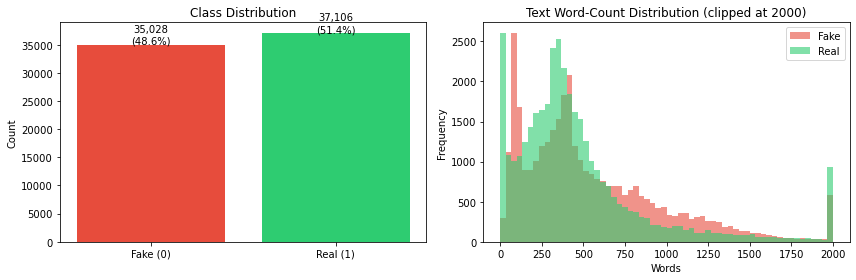


Text word-count stats:
         count   mean    std  min    25%    50%    75%      max
label                                                          
0      35028.0  577.6  563.1  0.0  241.0  427.0  783.0  14641.0
1      37106.0  505.6  677.1  0.0  217.0  369.0  568.0  24234.0

Title word-count stats:
         count  mean  std  min   25%   50%   75%   max
label                                                 
0      35028.0  11.0  2.9  2.0   9.0  11.0  13.0  30.0
1      37106.0  13.2  5.0  0.0  10.0  13.0  16.0  72.0


In [20]:

# --- Class distribution ---
label_counts = df_raw['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar
axes[0].bar(['Fake (0)', 'Real (1)'], label_counts.values, color=['#e74c3c', '#2ecc71'])
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({v/len(df_raw)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# Text-length distribution by class
df_raw['text_len'] = df_raw['text'].fillna('').str.split().str.len()
for lbl, color, name in [(0,'#e74c3c','Fake'), (1,'#2ecc71','Real')]:
    subset = df_raw[df_raw['label'] == lbl]['text_len'].clip(0, 2000)
    axes[1].hist(subset, bins=60, alpha=0.6, color=color, label=name)
axes[1].set_title('Text Word-Count Distribution (clipped at 2000)')
axes[1].set_xlabel('Words')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

# Title lengths
df_raw['title_len'] = df_raw['title'].fillna('').str.split().str.len()
print("\nText word-count stats:")
print(df_raw.groupby('label')['text_len'].describe().round(1))
print("\nTitle word-count stats:")
print(df_raw.groupby('label')['title_len'].describe().round(1))

In [21]:
# Very short texts — potential noise
short_thresh = 10  # words
short_texts = df_raw[df_raw['text_len'] < short_thresh]
print(f"Texts with fewer than {short_thresh} words: {len(short_texts)} ({len(short_texts)/len(df_raw)*100:.2f}%)")
short_texts[['title', 'text', 'label']].head(10)

Texts with fewer than 10 words: 1233 (1.71%)


,title,text,label
1,NaN,Did they post their votes for Hillary already?,1
7,HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...,,1
79,‘Arab Spring’ and the Washington-Brussels-Riya...,Be the First to Comment! Search articles,1
106,MARKETWATCH LEFTIST: MSM’s “Blatant” Anti Trum...,,1
185,NaN,Cool,1
244,WORLD WAR 3 IS COMING,source Add To The Conversation Using Facebook ...,1
325,Ohio State University Student Says Terrorist A...,,1
358,NaN,Obamas blunder.,1
364,JULIAN ASSANGE REVEALS John Podesta’s Hilariou...,,1
421,HEATED! TUCKER CARLSON Totally Shuts Down Radi...,https://www.youtube.com/watch?v=RRPSCqkAJgk,1


# Data Cleaning

In [22]:
df = df_raw.copy()

# Drop nulls in critical columns
df = df.dropna(subset=['title', 'text'])

# Drop whitespace-only text
df = df[df['text'].str.strip() != '']
df = df[df['title'].str.strip() != '']

# Drop (title, text) duplicates
df = df.drop_duplicates(subset=['title', 'text'])

# Drop very short texts (likely corrupt / empty articles)
df = df[df['text_len'] >= 10]

df = df.reset_index(drop=True)
print(f"After cleaning: {df.shape}  (removed {len(df_raw) - len(df)} rows)")
print(f"  Fake: {(df['label']==0).sum()} | Real: {(df['label']==1).sum()}")

After cleaning: (62338, 5)  (removed 9796 rows)
  Fake: 34782 | Real: 27556


# Feature Engineering

Fake news articles tend to be shorter/excessively long

In [23]:
df['title_word_count'] = df['title'].str.split().str.len()
df['text_word_count']  = df['text'].str.split().str.len()
df['text_char_count']  = df['text'].str.len()

print(df[['title_word_count', 'text_word_count', 'text_char_count']].describe().round(1))

       title_word_count  text_word_count  text_char_count
count           62338.0          62338.0          62338.0
mean               12.0            553.5           3344.4
std                 3.8            612.0           3644.9
min                 1.0             10.0             46.0
25%                 9.0            249.0           1509.0
50%                11.0            407.0           2492.0
75%                14.0            683.0           4149.0
max                72.0          24234.0         142961.0


# Text Preprocessing Pipeline
1) Added negation handling. E.g. don't -> do not which then "not" is included after stopword removal where don't would not have been included despite having the word "not"
2) POS-aware lemmatisation. i.e. lemmatises verbs, adj, and adverbs correctly, not just nouns (which is default NLTK behavior)
3) Saves both a token list column and a joined-string column for TF-IDF/CountVectoriser use

In [24]:
# Negation expansion map
NEGATION_MAP = {
    r"won't": "will not", r"can't": "cannot", r"n't": " not",
    r"'re": " are", r"'s": " is", r"'d": " would",
    r"'ll": " will", r"'ve": " have", r"'m": " am"
}

def expand_contractions(text):
    for pattern, replacement in NEGATION_MAP.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    return text

# POS tag → WordNet POS
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN  # default

# Main Pipeline
_lemmatizer = WordNetLemmatizer()
_stop_words = set(stopwords.words('english')) - {'not', 'no', 'nor'}  # keep negations

def preprocess_text(text):
    """Full cleaning + tokenisation pipeline. Returns a list of tokens."""
    text = str(text)
    text = expand_contractions(text)         # e.g. don't -> do not
    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # remove URLs
    text = re.sub(r'<[^>]+>', ' ', text)                 # strip HTML
    text = re.sub(r'[0-9]+', '', text)                   # remove digits
    text = re.sub(r'[^a-z\s]', ' ', text)               # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()             # normalise whitespace

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if re.match(r'^[a-z]+$', t)]  # alphabetic only
    tokens = [t for t in tokens if t not in _stop_words]       # stopword removal

    # POS-aware lemmatisation
    pos_tags = nltk.pos_tag(tokens)
    tokens = [_lemmatizer.lemmatize(w, get_wordnet_pos(pos)) for w, pos in pos_tags]

    return tokens

print('✓ Preprocessing functions defined')

✓ Preprocessing functions defined


In [26]:
# Apply to title and text
print("Processing title...")
df['title_tokens'] = df['title'].apply(preprocess_text)

print("Processing text...")
df['text_tokens'] = df['text'].apply(preprocess_text)

# Also save as joined strings for TF-IDF / CountVectorizer
df['title_cleaned'] = df['title_tokens'].apply(lambda t: ' '.join(t))
df['text_cleaned']  = df['text_tokens'].apply(lambda t: ' '.join(t))

print(f'✓ Done. Sample title_tokens: {df["title_tokens"].iloc[0][:10]}')

Processing title...
Processing text...


KeyboardInterrupt: 

# Post-processing QC

In [ ]:
df['token_count'] = df['text_tokens'].str.len()

# Any texts reduced to empty after cleaning?
empty_after = df[df['token_count'] == 0]
print(f"Rows with 0 tokens after cleaning: {len(empty_after)}")
if len(empty_after):
    df = df[df['token_count'] > 0].reset_index(drop=True)
    print("  → Dropped.")

# Vocabulary sizes
all_tokens = [t for tokens in df['text_tokens'] for t in tokens]
vocab = set(all_tokens)
print(f"\nVocabulary size: {len(vocab):,}")
print(f"Total tokens: {len(all_tokens):,}")

# Top 20 tokens per class
for lbl, name in [(0,'Fake'), (1,'Real')]:
    class_tokens = [t for tokens in df[df['label']==lbl]['text_tokens'] for t in tokens]
    top20 = Counter(class_tokens).most_common(20)
    print(f"\nTop 20 tokens — {name}: {[w for w,_ in top20]}")

In [ ]:
# Token count distribution after cleaning
plt.figure(figsize=(10, 4))
for lbl, color, name in [(0,'#e74c3c','Fake'), (1,'#2ecc71','Real')]:
    df[df['label']==lbl]['token_count'].clip(0, 1500).plot.hist(
        bins=60, alpha=0.6, color=color, label=name)
plt.title('Token Count After Cleaning')
plt.xlabel('Token count')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Columns to keep in final CSV
save_cols = ['title', 'text', 'label',
             'title_word_count', 'text_word_count', 'text_char_count',
             'title_cleaned', 'text_cleaned',
             'title_tokens', 'text_tokens', 'token_count']

df[save_cols].to_csv('processed_text.csv', index=False)
print(f'✓ Saved processed_text.csv  ({df.shape[0]:,} rows)')

# Final shape & distribution check
print(f"\nFinal dataset: {df.shape}")
print(f"  Fake (0): {(df['label']==0).sum():,}  ({(df['label']==0).mean()*100:.1f}%)")
print(f"  Real (1): {(df['label']==1).sum():,}  ({(df['label']==1).mean()*100:.1f}%)")

# Start of Image Preprocessing

In [29]:
from pathlib import Path

BASE_DIR      = Path('/Users/zan_zxc/Downloads/CASIA2.0_revised')
AUTHENTIC_DIR = BASE_DIR / 'Au'
TAMPERED_DIR  = BASE_DIR / 'Tp'
MASK_DIR      = BASE_DIR / 'CASIA 2 Groundtruth'

AU_LIST = BASE_DIR / 'au_list.txt'
TP_LIST = BASE_DIR / 'tp_list.txt'

au_names = [n.strip() for n in AU_LIST.read_text().strip().splitlines() if n.strip()]
tp_names = [n.strip() for n in TP_LIST.read_text().strip().splitlines() if n.strip()]

print(f"Authentic images listed: {len(au_names)}")
print(f"Tampered  images listed: {len(tp_names)}")

Authentic images listed: 7491
Tampered  images listed: 5123


# EDA for images

In [30]:
def analyse_image_set(names, folder, label, sample_size=200):
    """Return a DataFrame with per-image metadata."""
    records = []
    sample = np.random.default_rng(RANDOM_STATE).choice(
        names, min(sample_size, len(names)), replace=False)
    for name in sample:
        path = folder / name
        try:
            img = Image.open(path)
            w, h = img.size
            records.append({
                'filename': name,
                'label': label,
                'width': w, 'height': h,
                'aspect_ratio': round(w / h, 3),
                'format': Path(name).suffix.lower(),
                'mode': img.mode,    # RGB, RGBA, L (grayscale), etc.
                'n_channels': len(img.getbands()),
            })
        except Exception as e:
            records.append({'filename': name, 'label': label, 'error': str(e)})
    return pd.DataFrame(records)

au_meta = analyse_image_set(au_names, AUTHENTIC_DIR, 0, sample_size=200)
tp_meta = analyse_image_set(tp_names, TAMPERED_DIR, 1, sample_size=200)
meta_df = pd.concat([au_meta, tp_meta], ignore_index=True)

print(meta_df.groupby('label')[['width','height','aspect_ratio']].describe().round(1))

       width                                                  height         \
       count   mean    std    min    25%    50%    75%    max  count   mean   
label                                                                         
0      200.0  398.2  132.9  240.0  384.0  384.0  384.0  800.0  200.0  318.4   
1      200.0  470.0  162.8  240.0  384.0  384.0  574.5  800.0  200.0  358.6   

       ...               aspect_ratio                                     
       ...    75%    max        count mean  std  min  25%  50%  75%  max  
label  ...                                                                
0      ...  384.0  800.0        200.0  1.3  0.3  0.7  1.3  1.5  1.5  1.7  
1      ...  422.0  800.0        200.0  1.4  0.3  0.6  1.3  1.5  1.5  1.8  

[2 rows x 24 columns]


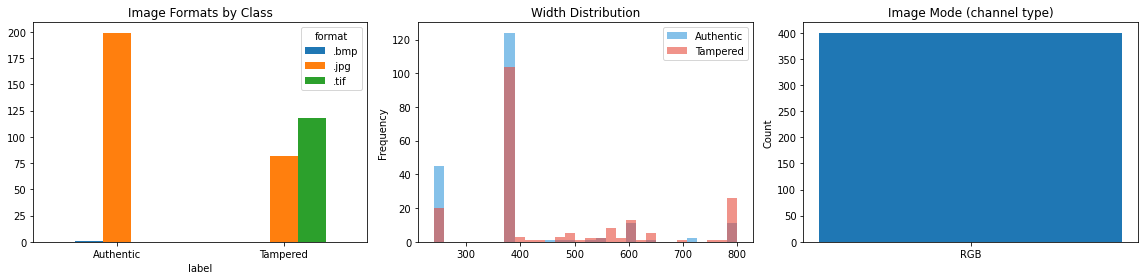


⚠ Non-RGB images in sample: 0 → will be converted to RGB during preprocessing
Empty DataFrame
Columns: [filename, label, mode]
Index: []


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Format breakdown
fmt_counts = meta_df.groupby(['label','format']).size().unstack(fill_value=0)
fmt_counts.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Image Formats by Class')
axes[0].set_xticklabels(['Authentic','Tampered'])

# Width distribution
for lbl, color, name in [(0,'#3498db','Authentic'), (1,'#e74c3c','Tampered')]:
    meta_df[meta_df['label']==lbl]['width'].plot.hist(
        bins=30, alpha=0.6, color=color, label=name, ax=axes[1])
axes[1].set_title('Width Distribution')
axes[1].legend()

# Channel / mode breakdown where non-RGB images need explicit handling
mode_counts = meta_df['mode'].value_counts()
axes[2].bar(mode_counts.index, mode_counts.values)
axes[2].set_title('Image Mode (channel type)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

non_rgb = meta_df[meta_df['mode'] != 'RGB']
print(f"\n⚠ Non-RGB images in sample: {len(non_rgb)} → will be converted to RGB during preprocessing")
print(non_rgb[['filename','label','mode']].head(10))

# Build Metadata df & Stratified train/test split

I split here first before preprocessing actually takes place such that augmentation only touches the training set and not the test set, i.e. test set is raw

In [32]:
records = []
for name in au_names:
    p = AUTHENTIC_DIR / name
    if p.exists():
        records.append({'filename': name, 'image_path': str(p), 'label': 0, 'label_name': 'Authentic'})

for name in tp_names:
    p = TAMPERED_DIR / name
    if p.exists():
        records.append({'filename': name, 'image_path': str(p), 'label': 1, 'label_name': 'Tampered'})
        # Attach mask path if available
        mask_name = Path(name).stem + '_gt.png'
        mask_path = MASK_DIR / mask_name
        records[-1]['mask_path'] = str(mask_path) if mask_path.exists() else None

img_df = pd.DataFrame(records)
print(f"Total images found: {len(img_df)}")
print(img_df['label_name'].value_counts())

# Stratified 80 / 10 / 10 split
train_df, temp_df = train_test_split(img_df, test_size=0.20, stratify=img_df['label'], random_state=RANDOM_STATE)
val_df,  test_df  = train_test_split(temp_df,  test_size=0.50, stratify=temp_df['label'],  random_state=RANDOM_STATE)

print(f"\nSplit sizes:")
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"  {name}: {len(split):4d}  "
          f"(Au={( split['label']==0).sum()}, Tp={(split['label']==1).sum()})")

# Save metadata CSV
img_df['split'] = 'train'
img_df.loc[val_df.index,  'split'] = 'val'
img_df.loc[test_df.index, 'split'] = 'test'
img_df.to_csv('image_metadata.csv', index=False)
print("\n✓ Saved image_metadata.csv")

Total images found: 12614
label_name
Authentic    7491
Tampered     5123
Name: count, dtype: int64

Split sizes:
  Train: 10091  (Au=5993, Tp=4098)
  Val: 1261  (Au=749, Tp=512)
  Test: 1262  (Au=749, Tp=513)

✓ Saved image_metadata.csv


In [34]:
#Helper Functions
TARGET_SIZE = (224, 224)

# ImageNet stats for pretrained CNN normalisation (ResNet, EfficientNet, ViT, etc.)
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)


def load_image(path, target_size=TARGET_SIZE):
    """Load image, force RGB (handles grayscale/RGBA/CMYK), resize with LANCZOS."""
    img = Image.open(path).convert('RGB')  
    img = img.resize(target_size, Image.LANCZOS)
    return np.array(img, dtype=np.float32)


def normalize_01(img_array):
    """Scale pixel values to [0, 1]."""
    return img_array / 255.0


def normalize_imagenet(img_array):
    """ImageNet mean/std normalisation — use for pretrained CNNs."""
    img = img_array / 255.0
    return (img - IMAGENET_MEAN) / IMAGENET_STD


def load_mask(mask_path, target_size=TARGET_SIZE):
    """Load ground-truth mask as binary [0, 1] array."""
    if mask_path is None:
        return None
    mask = Image.open(mask_path).convert('L')   # grayscale
    mask = mask.resize(target_size, Image.Resampling.NEAREST)
    arr  = np.array(mask, dtype=np.float32)
    return (arr > 127).astype(np.float32)        # binarise


print('Image helpers defined')

Image helpers defined


In [36]:
# Check how many paths actually exist for each split
for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    total = len(split_df)
    exists = sum(1 for p in split_df['image_path'] if Path(p).exists())
    print(f"{split_name}: {exists}/{total} files found on disk")

# Print a few sample paths so we can see what they look like
print("\nSample paths from train_df:")
for p in train_df['image_path'].head(3):
    print(f"  exists={Path(p).exists()}  path={p}")

train: 10091/10091 files found on disk
val: 1261/1261 files found on disk
test: 1262/1262 files found on disk

Sample paths from train_df:
  exists=True  path=/Users/zan_zxc/Downloads/CASIA2.0_revised/Tp/Tp_S_NNN_M_N_pla10126_pla10126_12127.jpg
  exists=True  path=/Users/zan_zxc/Downloads/CASIA2.0_revised/Tp/Tp_S_NNN_M_N_ani10125_ani10125_12396.jpg
  exists=True  path=/Users/zan_zxc/Downloads/CASIA2.0_revised/Tp/Tp_S_NRN_S_N_ani00005_ani00005_00125.tif


# Actual Processing is done here

In [37]:
OUTPUT_DIR = Path('/Users/zan_zxc/Downloads/preprocessed_casia')
OUTPUT_DIR.mkdir(exist_ok=True)

# Choose normalisation mode:
#   'simple' good for custom CNNs trained from scratch
#   'imagenet' required for pretrained ResNet/EfficientNet/ViT
NORM_MODE = 'imagenet'
normalize_fn = normalize_imagenet if NORM_MODE == 'imagenet' else normalize_01

def process_split(split_df, split_name, augment=False):
    images, labels, filenames = [], [], []
    failed = []

    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=split_name):
        try:
            arr = load_image(row['image_path'])
            arr = normalize_fn(arr)

            if augment:
                if np.random.rand() > 0.5:
                    arr = arr[:, ::-1, :]
                if np.random.rand() > 0.5:
                    arr = arr[::-1, :, :]
                factor = np.random.uniform(0.85, 1.15)
                arr = np.clip(arr * factor, 0, 1) if NORM_MODE == 'simple' else arr

            images.append(arr)
            labels.append(row['label'])
            filenames.append(row['filename'])

        except Exception as e:
            failed.append((row['filename'], str(e)))

    print(f"\n  Processed: {len(images)} | Failed: {len(failed)}")
    if failed:
        print("  First 5 failures:")
        for fname, err in failed[:5]:
            print(f"    {fname}: {err}")

    if len(images) == 0:
        print(f"   ERROR: No images were successfully processed for {split_name}!")
        return None, None, None

    X = np.array(images, dtype=np.float32)
    y = np.array(labels)
    f = np.array(filenames)

    out_path = OUTPUT_DIR / f'casia_{split_name}.npz'
    np.savez_compressed(out_path, images=X, labels=y, filenames=f)
    print(f'  Saved {out_path}  shape={X.shape}')
    return X, y, f


X_train, y_train, f_train = process_split(train_df, 'train', augment=True)
X_val,   y_val,   f_val   = process_split(val_df,   'val',   augment=False)
X_test,  y_test,  f_test  = process_split(test_df,  'test',  augment=False)

print(f'\n✓ Done  (norm_mode={NORM_MODE})')

train: 100%|██████████| 10091/10091 [00:36<00:00, 274.79it/s]



  Processed: 0 | Failed: 10091
  First 5 failures:
    Tp_S_NNN_M_N_pla10126_pla10126_12127.jpg: module 'PIL.Image' has no attribute 'Resampling'
    Tp_S_NNN_M_N_ani10125_ani10125_12396.jpg: module 'PIL.Image' has no attribute 'Resampling'
    Tp_S_NRN_S_N_ani00005_ani00005_00125.tif: module 'PIL.Image' has no attribute 'Resampling'
    Tp_S_NNN_S_N_arc20014_arc20014_01467.tif: module 'PIL.Image' has no attribute 'Resampling'
    Tp_S_NRN_S_B_ani20004_ani20004_02403.tif: module 'PIL.Image' has no attribute 'Resampling'
   ERROR: No images were successfully processed for train!


val: 100%|██████████| 1261/1261 [00:04<00:00, 289.74it/s]



  Processed: 0 | Failed: 1261
  First 5 failures:
    Au_nat_20080.jpg: module 'PIL.Image' has no attribute 'Resampling'
    Au_art_20024.jpg: module 'PIL.Image' has no attribute 'Resampling'
    Au_arc_30033.jpg: module 'PIL.Image' has no attribute 'Resampling'
    Au_nat_20075.jpg: module 'PIL.Image' has no attribute 'Resampling'
    Tp_D_NRN_S_B_arc00042_ani00070_00262.tif: module 'PIL.Image' has no attribute 'Resampling'
   ERROR: No images were successfully processed for val!


test: 100%|██████████| 1262/1262 [00:21<00:00, 60.06it/s]


  Processed: 0 | Failed: 1262
  First 5 failures:
    Tp_S_CRD_S_N_ind00039_ind00039_01330.tif: module 'PIL.Image' has no attribute 'Resampling'
    Tp_D_NRN_S_B_nat00015_cha00014_20052.jpg: module 'PIL.Image' has no attribute 'Resampling'
    Tp_S_NNN_S_N_sec00082_sec00082_10363.tif: module 'PIL.Image' has no attribute 'Resampling'
    Tp_S_NNN_S_N_art20021_art20021_01827.tif: module 'PIL.Image' has no attribute 'Resampling'
    Au_arc_00074.jpg: module 'PIL.Image' has no attribute 'Resampling'
   ERROR: No images were successfully processed for test!

✓ Done  (norm_mode=imagenet)


# Sanity Check

In [38]:
# Display samples from train split
# If using imagenet normalisation, de-normalise for display
def display_img(arr):
    if NORM_MODE == 'imagenet':
        arr = arr * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(arr, 0, 1)

idx = np.random.choice(len(X_train), 8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f'Train Samples (norm={NORM_MODE}, augmented)', fontsize=13)
for ax, i in zip(axes.flat, idx):
    ax.imshow(display_img(X_train[i]))
    ax.set_title('Authentic' if y_train[i] == 0 else 'Tampered', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

TypeError: object of type 'NoneType' has no len()